# Bolted Field Splice Designer — guide & validation

`civilpy.structural.aashto.lrfd.design_splice` designs a **bolted field splice
for a steel plate girder** to AASHTO LRFD 6.13.6.1: given the girder section on
each side of the splice, the splice-centerline loads, and the bolt / splice-plate
/ clearance selections, it

1. **sizes** the flange and web bolt groups,
2. **lays out** the bolt pattern (gage, pitch, edge, end) and splice-plate sizes,
3. **checks** the AASHTO limit states and reports OK / NOTICE per article.

This notebook has two parts:

* **Part 1 — Using the designer**: a quick-start example, a reference for every
  input, how to read the result object, a design-iteration example, and a
  bolt-layout drawing.
* **Part 2 — Validation**: the designer run against two independently worked
  plate-girder splices (the NSBA *Bolted Splice Designer – Plate Girder v3.16*
  workbooks kept in this folder), compared article-by-article.

**AASHTO articles exercised:** 6.13.6.1.3b (flange design force *Pfy*),
6.13.6.1.3c (web forces / *Hw*), 6.13.2.7 (bolt shear), 6.13.2.8 (slip),
6.13.2.9 (bearing), 6.13.4 (block shear), 6.13.5.2 (net section), 6.13.6.1.4
(filler *R*), 6.13.2.6 (spacing), 6.10.9 (web shear), D6.1 (slab crushing).

**Units throughout: kip, inch, ksi**; moments are supplied in **kip-ft**.

> The NSBA workbooks are copyrighted; only their *numeric* results are used here
> as ground truth — transcribed into this notebook as literals, so it runs
> without the `.xlsx` files. civilpy contains only the AASHTO equations and
> article numbers — no workbook formulas or prose.


In [1]:
%matplotlib inline
import dataclasses

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd

from civilpy.structural.aashto.lrfd import (
    design_splice, SpliceInput, Flange, GirderSide, SpliceLoads, BoltSpec,
    PlatePair, WebPlate,
)
from civilpy.structural.aashto.lrfd.bolted_field_splice import (
    STEEL_GRADES, BOLT_FU, STANDARD_HOLE_DIA,
)
from civilpy.structural.aashto.lrfd.steel import (
    SLIP_SURFACE_FACTORS, SLIP_HOLE_FACTORS, BOLT_PRETENSION,
)

pd.set_option("display.max_rows", 200)


def summary_table(d):
    # one-look summary of a SpliceDesign: bolts, layout, plate, verdict
    rows = []
    for c in d.components:
        rows.append({
            "component": c.name,
            "rows/side": c.bolt_rows,
            "bolts/side": c.total_bolts,
            "pitch": c.pitch,
            "plate w x L x t (in)":
                f"{c.plate_width} x {round(c.plate_length, 2)} x {c.plate_thickness}",
            "ok": c.ok,
        })
    return pd.DataFrame(rows)

# Part 1 — Using the designer

## 1.1 Quick start

A splice is described by one `SpliceInput`. Below is a symmetric composite
plate girder (same section each side). The seven structured inputs — `left`,
`right`, `loads`, `bolts`, `top_plates`, `bottom_plates`, `web_plate` — are
required; everything else (deck, bolt counts per row, spacing, clearances) has a
sensible default. `design_splice` returns a `SpliceDesign`.

In [2]:
def quick_start_input():
    # one section, used on both sides of the splice
    side = GirderSide(
        top_flange=Flange("Grade 50", 1.0, 15.0),      # material, t (in), w (in)
        bottom_flange=Flange("Grade 50", 1.25, 17.0),
        web_material="Grade 50W", web_thickness=0.5, web_depth=60.0,
        haunch=1.0, stiffener_spacing_ft=15.0, stiffened=True,
    )
    return SpliceInput(
        left=side, right=side,
        loads=SpliceLoads(                              # unfactored, kip-ft / kip
            dc1_m=200, dc1_v=-60, dc2_m=40, dc2_v=-10, dw_m=40, dw_v=-10,
            ll_pos_m=1400, ll_pos_v=20, ll_neg_m=-900, ll_neg_v=-90,
            deck_cast_m=800, deck_cast_v=-55),
        bolts=BoltSpec(),                               # A325, 7/8 in, defaults
        top_plates=PlatePair("Grade 50", 0.75, 6.5, 0.6875, 15.0),
        bottom_plates=PlatePair("Grade 50", 0.875, 7.0, 0.8125, 17.0),
        web_plate=WebPlate("Grade 50", 0.375),
        deck_composite=True, deck_thickness=8.5, deck_eff_width=96.0, fc=4.0,
        flange_end=1.5, web_end=1.5,
    )


d_qs = design_splice(quick_start_input())
print("overall design ok:", d_qs.ok)
summary_table(d_qs)

overall design ok: True


,component,rows/side,bolts/side,pitch,plate w x L x t (in),ok
0,top_flange,4,12,3.000,15.0 x 18.75 x 0.6875,True
1,bottom_flange,4,16,3.000,17.0 x 24.75 x 0.8125,True
2,web,2,22,5.125,14.75 x 54.25 x 0.375,True


## 1.2 Inputs reference

Every input and its default. The seven **structured** inputs are dataclasses;
the remaining **scalar** inputs live directly on `SpliceInput`.

In [3]:
def _describe(cls, notes):
    rows = []
    for f in dataclasses.fields(cls):
        if f.default is not dataclasses.MISSING:
            default = f.default
        elif f.default_factory is not dataclasses.MISSING:      # noqa
            default = f.default_factory()
        else:
            default = "— (required)"
        rows.append({"field": f.name, "default": default,
                     "meaning / units": notes.get(f.name, "")})
    return pd.DataFrame(rows)


print("SpliceInput — scalar inputs (structured ones shown separately below):")
_describe(SpliceInput, {
    "left": "GirderSide on the left of the splice (see below)",
    "right": "GirderSide on the right of the splice",
    "loads": "SpliceLoads — unfactored splice-centerline demands",
    "bolts": "BoltSpec — bolt type / size / faying surface",
    "top_plates": "PlatePair — top-flange inner+outer splice plates",
    "bottom_plates": "PlatePair — bottom-flange splice plates",
    "web_plate": "WebPlate — web splice plate",
    "deck_composite": "deck acts compositely with the steel section",
    "deck_thickness": "structural deck thickness ts (in)",
    "deck_eff_width": "effective deck width for slab crushing (in)",
    "fc": "deck concrete strength f'c (ksi)",
    "top_flange_rows": "transverse bolt rows, top flange (per side)",
    "bottom_flange_rows": "transverse bolt rows, bottom flange (per side)",
    "web_rows": "vertical bolt lines, web (per side)",
    "bolt_spacing": "bolt pitch & gage within a group (in)",
    "flange_edge": "flange-plate transverse edge distance (in)",
    "flange_end": "flange-plate longitudinal end distance (in)",
    "web_edge": "web-plate edge distance (in)",
    "web_end": "web-plate end distance (in)",
    "web_weld_size": "web-to-flange weld size (in)",
    "web_weld_clearance": "clearance beside the web weld (in)",
    "girder_gap": "gap between girder ends at the splice (in)",
    "entering_tightening": "wrench entering & tightening clearance (in)",
    "design_year": "AASHTO edition; >=2017 uses the 0.56/0.45 bolt-shear "
                   "coefficient, earlier uses 0.48/0.38",
}).iloc[7:].reset_index(drop=True)

SpliceInput — scalar inputs (structured ones shown separately below):


,field,default,meaning / units
0,deck_composite,True,deck acts compositely with the steel section
1,deck_thickness,0.0,structural deck thickness ts (in)
2,deck_eff_width,0.0,effective deck width for slab crushing (in)
3,fc,4.0,deck concrete strength f'c (ksi)
4,top_flange_rows,4,"transverse bolt rows, top flange (per side)"
5,bottom_flange_rows,4,"transverse bolt rows, bottom flange (per side)"
6,web_rows,2,"vertical bolt lines, web (per side)"
7,bolt_spacing,3.0,bolt pitch & gage within a group (in)
8,flange_edge,2.0,flange-plate transverse edge distance (in)
9,flange_end,1.5,flange-plate longitudinal end distance (in)


In [4]:
tables = {
    "Flange (one flange, one side)": _describe(Flange, {
        "material": "steel grade (see grades table)",
        "thickness": "flange thickness (in)", "width": "flange width (in)"}),
    "GirderSide (one side of the splice)": _describe(GirderSide, {
        "top_flange": "Flange", "bottom_flange": "Flange",
        "web_material": "web steel grade", "web_thickness": "web t (in)",
        "web_depth": "clear web depth D (in)", "haunch": "haunch depth (in)",
        "stiffener_spacing_ft": "transverse stiffener spacing do (ft); None if "
                                "unstiffened",
        "stiffened": "web is transversely stiffened"}),
    "PlatePair (inner + outer flange splice plates)": _describe(PlatePair, {
        "material": "plate steel grade",
        "inner_thickness": "each inner plate t (in)",
        "inner_width": "each inner plate width (in)",
        "outer_thickness": "outer plate t (in)", "outer_width": "outer w (in)",
        "shear_planes": "bolt shear planes Ns (2 = double shear)"}),
    "WebPlate": _describe(WebPlate, {
        "material": "plate steel grade", "thickness": "each web plate t (in)",
        "shear_planes": "bolt shear planes Ns"}),
    "BoltSpec": _describe(BoltSpec, {
        "bolt_type": "A325 or A490", "diameter": "bolt diameter (in)",
        "flange_threads_excluded": "threads excluded from flange shear planes",
        "web_threads_excluded": "threads excluded from web shear planes",
        "surface_class": "faying-surface class Ks (A/B/C/D)",
        "hole_type": "standard / oversize / long_slot_perp / long_slot_par"}),
    "SpliceLoads (unfactored; _m = moment kip-ft, _v = shear kip)": _describe(
        SpliceLoads, {
            "dc1_m": "noncomposite dead load DC1", "dc1_v": "",
            "dc2_m": "composite dead load DC2", "dc2_v": "",
            "dw_m": "future wearing surface DW", "dw_v": "",
            "ll_pos_m": "positive live load + impact", "ll_pos_v": "",
            "ll_neg_m": "negative live load + impact", "ll_neg_v": "",
            "deck_cast_m": "deck-casting sequence", "deck_cast_v": ""}),
}
for title, tbl in tables.items():
    print(f"\n### {title}")
    display(tbl)


### Flange (one flange, one side)


,field,default,meaning / units
0,material,— (required),steel grade (see grades table)
1,thickness,— (required),flange thickness (in)
2,width,— (required),flange width (in)



### GirderSide (one side of the splice)


,field,default,meaning / units
0,top_flange,— (required),Flange
1,bottom_flange,— (required),Flange
2,web_material,— (required),web steel grade
3,web_thickness,— (required),web t (in)
4,web_depth,— (required),clear web depth D (in)
5,haunch,0.0,haunch depth (in)
6,stiffener_spacing_ft,None,transverse stiffener spacing do (ft); None if ...
7,stiffened,True,web is transversely stiffened



### PlatePair (inner + outer flange splice plates)


...

,field,default,meaning / units
0,material,— (required),plate steel grade
1,thickness,— (required),each web plate t (in)
2,shear_planes,2,bolt shear planes Ns



### BoltSpec


,field,default,meaning / units
0,bolt_type,A325,A325 or A490
1,diameter,0.875,bolt diameter (in)
2,flange_threads_excluded,True,threads excluded from flange shear planes
3,web_threads_excluded,False,threads excluded from web shear planes
4,surface_class,B,faying-surface class Ks (A/B/C/D)
5,hole_type,standard,standard / oversize / long_slot_perp / long_sl...



### SpliceLoads (unfactored; _m = moment kip-ft, _v = shear kip)


,field,default,meaning / units
0,dc1_m,0.0,noncomposite dead load DC1
1,dc1_v,0.0,
2,dc2_m,0.0,composite dead load DC2
3,dc2_v,0.0,
4,dw_m,0.0,future wearing surface DW
5,dw_v,0.0,
6,ll_pos_m,0.0,positive live load + impact
7,ll_pos_v,0.0,
8,ll_neg_m,0.0,negative live load + impact
9,ll_neg_v,0.0,


**Reference values** used internally — the allowed steel grades, bolt
ultimate strengths, standard hole diameters, faying-surface (Ks) and hole (Kh)
factors, and bolt pretension — pulled live from civilpy.

In [5]:
print("Steel grades  (Fy, Fu ksi):")
display(pd.DataFrame([(g, fy, fu) for g, (fy, fu) in STEEL_GRADES.items()],
                     columns=["grade", "Fy", "Fu"]))
print("Bolt Fu (ksi):", BOLT_FU)
print("Standard hole diameter by bolt dia (in):", STANDARD_HOLE_DIA)
print("Surface class Ks (6.13.2.8):", SLIP_SURFACE_FACTORS)
print("Hole factor Kh (6.13.2.8):", SLIP_HOLE_FACTORS)
print("Min bolt pretension Pt (kip), Table 6.13.2.8-1:",
      {f"{g} {d}\"": pt for (g, d), pt in BOLT_PRETENSION.items()})

Steel grades  (Fy, Fu ksi):


,grade,Fy,Fu
0,Grade 36,36.0,58.0
1,Grade 50,50.0,65.0
2,Grade 50CR,50.0,70.0
3,Grade 50W,50.0,70.0
4,HPS Grade 50W,50.0,70.0
5,HPS Grade 70W,70.0,85.0
6,HPS Grade 100W,100.0,110.0


Bolt Fu (ksi): {'A325': 120.0, 'A490': 150.0}
Standard hole diameter by bolt dia (in): {0.625: 0.6875, 0.75: 0.8125, 0.875: 0.9375, 1.0: 1.125, 1.125: 1.25, 1.25: 1.375, 1.375: 1.5}
Surface class Ks (6.13.2.8): {'A': 0.33, 'B': 0.5, 'C': 0.33}
Hole factor Kh (6.13.2.8): {'standard': 1.0, 'oversize': 0.85, 'long_slot_perp': 0.7, 'long_slot_par': 0.6}
Min bolt pretension Pt (kip), Table 6.13.2.8-1: {'A325 0.625"': 19.0, 'A325 0.75"': 28.0, 'A325 0.875"': 39.0, 'A325 1.0"': 51.0, 'A325 1.125"': 56.0, 'A325 1.25"': 71.0, 'A490 0.625"': 24.0, 'A490 0.75"': 35.0, 'A490 0.875"': 49.0, 'A490 1.0"': 64.0, 'A490 1.125"': 80.0, 'A490 1.25"': 102.0}


## 1.3 Reading the result

`design_splice` returns a `SpliceDesign`:

* `.factored_moments` / `.factored_shears` — the governing load combinations
  (Strength I ±, Service II ±, deck casting).
* `.components` — three `ComponentDesign`s: `top_flange`, `web`, `bottom_flange`
  (also on the design as attributes). Each carries the bolt count, layout,
  plate size, and a list of `.checks`.
* `.ok` — True only if every component's checks pass.

Each `.checks` entry is a `CheckResult` with `.article`, `.name`, `.capacity`,
`.demand`, `.factored_capacity` (= `phi * capacity`), `.ratio`
(`factored_capacity / demand`, ≥ 1 passes) and `.ok`.

In [6]:
d = d_qs
print("type:", type(d).__name__, "| overall ok:", d.ok)
print("factored moments (kip-ft):",
      {k: round(v, 1) for k, v in d.factored_moments.items()})

# anatomy of one component
c = d.top_flange
print(f"\n{c.name}: {c.total_bolts} bolts in {c.bolt_rows} rows; design force "
      f"Pfy = {c.design_force:.1f} kip; filler R = {c.extra['filler_R']:.3f}")
pd.DataFrame([{
    "article": chk.article, "check": chk.name,
    "phi*capacity": round(chk.factored_capacity, 1),
    "demand": None if chk.demand is None else round(chk.demand, 1),
    "ratio": None if chk.ratio is None else round(chk.ratio, 2),
    "ok": chk.ok,
} for chk in c.checks])

type: SpliceDesign | overall ok: True
factored moments (kip-ft): {'deck_cast': 1120.0, 'strength_pos': 2810.0, 'strength_neg': -1333.0, 'service_pos': 2100.0, 'service_neg': -890.0}

top_flange: 12 bolts in 4 rows; design force Pfy = 615.8 kip; filler R = 1.000


,article,check,phi*capacity,demand,ratio,ok
0,6.13.2.8,top flange Service II slip,468.0,174.7,2.68,True
1,6.13.5.2,outer plate yield (tension),489.8,307.9,1.59,True
2,6.13.5.2,Net Section Reduction Limit,8.8,7.7,1.13,True
3,6.13.6.1.3,outer plate net-section fracture,402.2,307.9,1.31,True
4,6.13.4,outer plate block shear,435.0,307.9,1.41,True
5,6.13.5.2,inner plate yield (tension),463.1,307.9,1.50,True
6,6.13.5.2,Net Section Reduction Limit,8.3,6.9,1.19,True
7,6.13.6.1.3,inner plate net-section fracture,360.8,307.9,1.17,True
8,6.13.4,inner plate block shear,474.6,307.9,1.54,True
9,6.13.4,girder flange block shear (Mode 1),784.5,615.8,1.27,True


**Interpreting the verdicts.** A check with a demand fails when its
capacity/demand ratio drops below 1.0. In the reference workbook a failing
*serviceability* item (Service II slip) or a flange that cannot carry the
splice moment (`Mflange`) is reported as a **NOTICE** — the splice can still be
detailed, but the engineer is warned. Here the same conditions surface as a
failing check, so scanning for `ok is False` finds them:

In [7]:
failing = [(c.name, chk.article, chk.name) for c in d.components
           for chk in c.checks if chk.ok is False]
print("failing checks:", failing or "none — all limit states pass")

# filler plates: engaged only where the two sides differ in flange thickness
print("\nfiller-plate reduction R per flange (1.0 = no filler):")
for c in (d.top_flange, d.bottom_flange):
    print(f"  {c.name:14} R = {c.extra['filler_R']:.4f}")

failing checks: none — all limit states pass

filler-plate reduction R per flange (1.0 = no filler):
  top_flange     R = 1.0000
  bottom_flange  R = 1.0000


## 1.4 Design iteration

Because the plates and bolt selections are *inputs*, designing is a loop: adjust
a value, re-run, read the result. `SpliceInput` is a frozen dataclass, so
`dataclasses.replace` makes a tweaked copy. Here we swap 7/8-in bolts for 1-in
bolts and watch the bolt counts and layout respond.

In [8]:
base = quick_start_input()
bigger = dataclasses.replace(base, bolts=BoltSpec(diameter=1.0))

cmp = summary_table(design_splice(base))[["component", "bolts/side", "pitch"]]
cmp = cmp.rename(columns={"bolts/side": "7/8in bolts", "pitch": "7/8in pitch"})
big = summary_table(design_splice(bigger))[["bolts/side", "pitch"]]
cmp["1in bolts"] = big["bolts/side"].values
cmp["1in pitch"] = big["pitch"].values
cmp

,component,7/8in bolts,7/8in pitch,1in bolts,1in pitch
0,top_flange,12,3.000,8,3.000
1,bottom_flange,16,3.000,12,3.000
2,web,22,5.125,22,5.125


## 1.5 Bolt-layout drawing

A quick plan/elevation of the designed bolt pattern and splice plates — the
notebook's answer to the workbook *Figures* sheet. Coordinates are reconstructed
from the `ComponentDesign` layout fields (gage, pitch, edge, end), with the
splice centerline at 0.

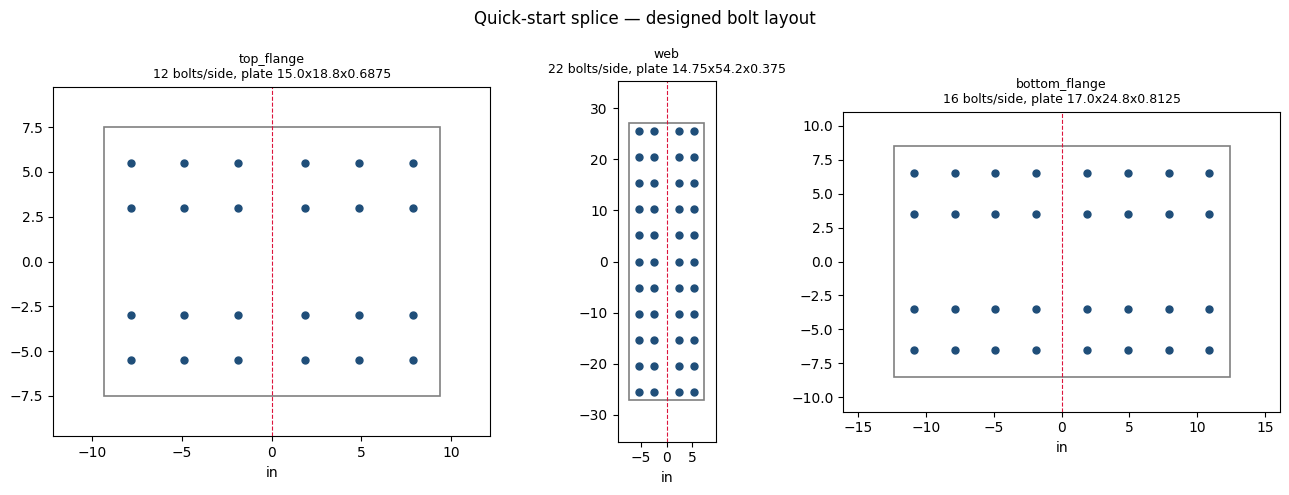

In [9]:
def _flange_xy(c):
    n_per_group = c.bolt_rows // 2
    ys, y = [], c.edge
    for g in range(2):
        for i in range(n_per_group):
            ys.append(y)
            if i < n_per_group - 1:
                y += c.gage_bolts
        if g == 0:
            y += c.gage_groups
    ys = [v - c.plate_width / 2 for v in ys]
    cols = c.total_bolts // c.bolt_rows
    xs = []
    for col in range(cols):
        d = c.pitch_groups / 2 + col * c.pitch
        xs += [d, -d]
    return xs, ys


def _web_xy(c):
    per_row = c.total_bolts // c.bolt_rows
    xs = []
    for line in range(c.bolt_rows):
        d = c.gage_groups / 2 + line * c.gage_bolts
        xs += [d, -d]
    ys = [(-(per_row - 1) / 2 + k) * c.pitch for k in range(per_row)]
    return xs, ys


def plot_splice_layout(design, title=""):
    fig, axes = plt.subplots(1, 3, figsize=(13, 5))
    panels = [("top_flange", design.top_flange, "plan"),
              ("web", design.web, "elev"),
              ("bottom_flange", design.bottom_flange, "plan")]
    for ax, (name, c, kind) in zip(axes, panels):
        if kind == "plan":
            xs, ys = _flange_xy(c)
            L, W = c.plate_length, c.plate_width           # x = long, y = width
        else:
            xs, ys = _web_xy(c)
            L, W = c.plate_width, c.plate_length           # x = width, y = height
        ax.add_patch(mpatches.Rectangle((-L / 2, -W / 2), L, W, fill=False,
                                        edgecolor="0.5", linewidth=1.2))
        for x in xs:
            for y in ys:
                ax.plot(x, y, "o", ms=5, color="#1f4e79")
        ax.axvline(0, ls="--", lw=0.8, color="crimson")   # splice centerline
        ax.set_title(f"{name}\n{c.total_bolts} bolts/side, plate "
                     f"{c.plate_width}x{round(c.plate_length, 1)}x"
                     f"{c.plate_thickness}", fontsize=9)
        ax.set_aspect("equal")
        ax.margins(0.15)
        ax.set_xlabel("in")
    fig.suptitle(title or "Bolt layout (splice centerline dashed)")
    fig.tight_layout()
    plt.show()


plot_splice_layout(d_qs, "Quick-start splice — designed bolt layout")

# Part 2 — Validation against the worked workbooks

The two `SpliceInput`s below mirror the **Input** sheet of each NSBA workbook.
Running them through `design_splice` and comparing to the workbook **Result** and
**Check** summaries is how we confirm the designer is correct.

In [10]:
def example_1_input():
    return SpliceInput(
        left=GirderSide(
            Flange("Grade 50W", 1.0, 16.0), Flange("Grade 50W", 1.375, 18.0),
            "Grade 50W", 0.5, 69.0, haunch=1.0,
            stiffener_spacing_ft=17.25, stiffened=True),
        right=GirderSide(
            Flange("HPS Grade 70W", 1.0, 18.0), Flange("HPS Grade 70W", 1.0, 20.0),
            "Grade 50W", 0.5625, 69.0, haunch=1.0,
            stiffener_spacing_ft=12.0, stiffened=True),
        loads=SpliceLoads(
            dc1_m=248, dc1_v=-82, dc2_m=50, dc2_v=-12, dw_m=52, dw_v=-11,
            ll_pos_m=2469, ll_pos_v=19, ll_neg_m=-1754, ll_neg_v=-112,
            deck_cast_m=1300, deck_cast_v=-82),
        bolts=BoltSpec("A325", 0.875, True, False, "B", "standard"),
        top_plates=PlatePair("Grade 50W", 0.6875, 7.0, 0.625, 16.0, 2),
        bottom_plates=PlatePair("Grade 50W", 0.875, 8.0, 0.75, 18.0, 2),
        web_plate=WebPlate("Grade 50W", 0.3125, 2),
        deck_composite=True, deck_thickness=9.0, deck_eff_width=144.0, fc=4.0,
        top_flange_rows=4, bottom_flange_rows=4, web_rows=2,
        bolt_spacing=3.0, flange_edge=2.0, flange_end=1.5,
        web_edge=2.0, web_end=1.5, web_weld_size=0.3125,
        web_weld_clearance=0.375, girder_gap=0.75, entering_tightening=3.0,
        design_year=2020)


def example_2_input():
    return SpliceInput(
        left=GirderSide(
            Flange("Grade 50", 1.0, 19.0), Flange("Grade 50", 1.4375, 20.0),
            "Grade 50W", 0.75, 109.0, haunch=2.0,
            stiffener_spacing_ft=0.0, stiffened=False),
        right=GirderSide(
            Flange("Grade 50", 2.0, 22.0), Flange("Grade 50", 2.25, 24.0),
            "Grade 50W", 0.75, 109.0, haunch=2.0,
            stiffener_spacing_ft=27.25, stiffened=True),
        loads=SpliceLoads(
            dc1_m=-1564, dc1_v=-147, dc2_m=-242, dc2_v=-28, dw_m=-315, dw_v=-37,
            ll_pos_m=5627, ll_pos_v=19, ll_neg_m=-7117, ll_neg_v=-126,
            deck_cast_m=3006, deck_cast_v=-79),
        bolts=BoltSpec("A325", 0.875, True, False, "B", "standard"),
        top_plates=PlatePair("Grade 50", 0.625, 8.5, 0.5625, 19.0, 2),
        bottom_plates=PlatePair("Grade 50", 0.875, 9.0, 0.8125, 20.0, 2),
        web_plate=WebPlate("Grade 50", 0.4375, 2),
        deck_composite=True, deck_thickness=8.0, deck_eff_width=114.0, fc=4.0,
        top_flange_rows=4, bottom_flange_rows=4, web_rows=2,
        bolt_spacing=3.0, flange_edge=2.0, flange_end=1.125,
        web_edge=2.0, web_end=1.75, web_weld_size=0.3125,
        web_weld_clearance=0.25, girder_gap=0.75, entering_tightening=3.0,
        design_year=2020)

The workbook ground-truth results (bolt counts and splice-plate dimensions) are
transcribed as literals above; the helpers below render the civilpy-vs-workbook
comparisons.

In [11]:
# Ground-truth results transcribed from the NSBA "Design Result Summary" sheet of
# each copyrighted workbook (bolts/side from C6:C8; plate thickness, width, length
# from A17:D21). Only these numeric results are reproduced here -- no workbook
# formulas or prose -- so the notebook validates standalone, without the .xlsx files.
WORKBOOK_BOLTS = {
    "example_1": {"top_flange": 12, "web": 26, "bottom_flange": 24},
    "example_2": {"top_flange": 20, "web": 66, "bottom_flange": 28},
}

WORKBOOK_PLATE_DIMS = {                     # label -> (thickness, width, length) in
    "example_1": {
        "Top Flange - Outer": (0.625, 16, 18.75),
        "Top Flange - Inner (Each)": (0.6875, 7, None),
        "Web": (0.3125, 14.75, 63),
        "Bottom Flange - Inner (Each)": (0.875, 8, 36.75),
        "Bottom Flange - Outer": (0.75, 18, None),
    },
    "example_2": {
        "Top Flange - Outer": (0.5625, 19, 29.25),
        "Top Flange - Inner (Each)": (0.625, 8.5, None),
        "Web": (0.4375, 14.75, 103.5),
        "Bottom Flange - Inner (Each)": (0.875, 9, 41.25),
        "Bottom Flange - Outer": (0.8125, 20, None),
    },
}


def bolt_count_table(design, ref):
    # ref: {component -> workbook bolts/side}, e.g. WORKBOOK_BOLTS["example_1"]
    rows = []
    for c in design.components:
        wb_n = ref[c.name]
        rows.append({"component": c.name, "rows": c.bolt_rows,
                     "civilpy bolts": c.total_bolts, "workbook bolts": wb_n,
                     "match": "OK" if c.total_bolts == wb_n else "DIFF",
                     "strength": c.strength_bolts, "slip": c.slip_bolts})
    return pd.DataFrame(rows)


def layout_table(design):
    rows = []
    for c in design.components:
        rows.append({"component": c.name, "gage_bolts": c.gage_bolts,
                     "gage_groups": c.gage_groups, "pitch": c.pitch,
                     "pitch_groups": c.pitch_groups, "edge": c.edge,
                     "end": c.end, "plate t": c.plate_thickness,
                     "plate w": c.plate_width,
                     "plate L": round(c.plate_length, 3)})
    return pd.DataFrame(rows)


def checks_table(component):
    return pd.DataFrame([{
        "article": chk.article, "check": chk.name,
        "phi*capacity": round(chk.factored_capacity, 2),
        "demand": None if chk.demand is None else round(chk.demand, 2),
        "ratio": None if chk.ratio is None else round(chk.ratio, 3),
        "verdict": "OK" if chk.ok is not False else "NG",
    } for chk in component.checks])

## Example 1 — composite plate girder (flanges resist the moment)

The common case: the flanges carry the full splice moment, so the web is sized
for shear plus the maximum-pitch (sealing) requirement. Every reference output
should match.

In [12]:
d1 = design_splice(example_1_input())
print("Factored design moments (kip-ft):",
      {k: round(v, 1) for k, v in d1.factored_moments.items()})
bolt_count_table(d1, WORKBOOK_BOLTS["example_1"])

Factored design moments (kip-ft): {'deck_cast': 1820.0, 'strength_pos': 4771.2, 'strength_neg': -2767.5, 'service_pos': 3559.7, 'service_neg': -1930.2}


,component,rows,civilpy bolts,workbook bolts,match,strength,slip
0,top_flange,4,12,12,OK,12,12
1,bottom_flange,4,24,24,OK,24,16
2,web,2,26,26,OK,10,8


**Layout & splice-plate sizes** vs the workbook Result Summary.

,component,gage_bolts,gage_groups,pitch,pitch_groups,edge,end,plate t,plate w,plate L
0,top_flange,3.0,6.00,3.0,3.75,2.0,1.5,0.6250,16.00,18.75
1,bottom_flange,4.0,6.00,3.0,3.75,2.0,1.5,0.7500,18.00,36.75
2,web,3.0,4.75,5.0,0.00,2.0,1.5,0.3125,14.75,63.00


workbook plate dims (thickness, width, length):
  Top Flange - Outer               (0.625, 16, 18.75)
  Top Flange - Inner (Each)        (0.6875, 7, None)
  Web                              (0.3125, 14.75, 63)
  Bottom Flange - Inner (Each)     (0.875, 8, 36.75)
  Bottom Flange - Outer            (0.75, 18, None)


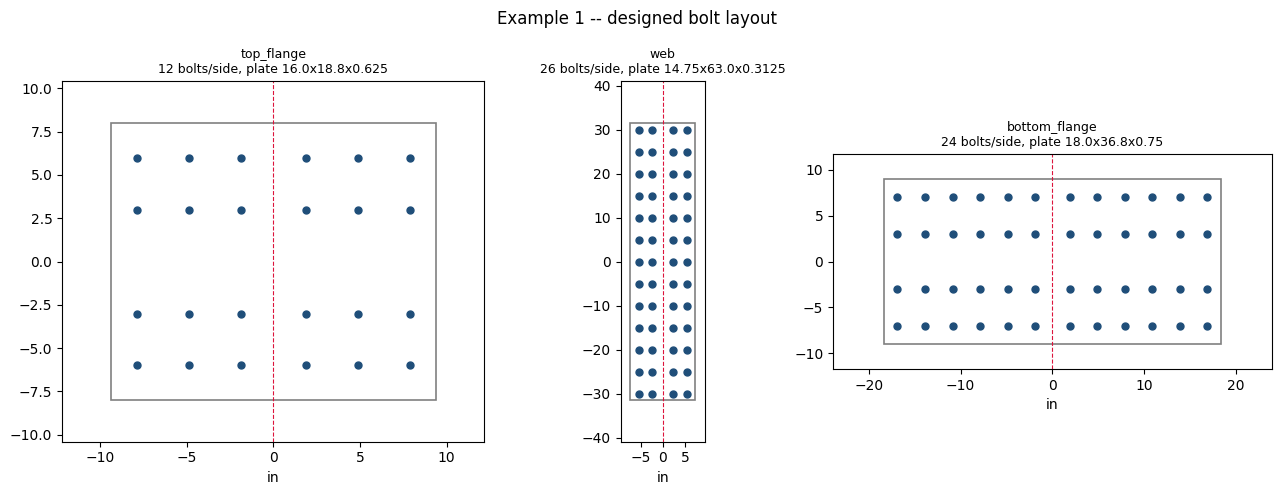

In [13]:
display(layout_table(d1))
print("workbook plate dims (thickness, width, length):")
for label, dims in WORKBOOK_PLATE_DIMS["example_1"].items():
    print(f"  {label:<32} {dims}")
plot_splice_layout(d1, "Example 1 -- designed bolt layout")

**Per-article limit-state checks — top flange.** Block shear governs
(Mode 2 = 737.45 kip factored vs the Mode 1 four-plane 900.9 kip); all pass.

In [14]:
checks_table(d1.top_flange)

,article,check,phi*capacity,demand,ratio,verdict
0,6.13.2.8,top flange Service II slip,468.00,330.01,1.418,OK
1,6.13.5.2,outer plate yield (tension),475.00,361.05,1.316,OK
2,6.13.5.2,Net Section Reduction Limit,8.50,7.66,1.110,OK
3,6.13.6.1.3,outer plate net-section fracture,428.75,361.05,1.188,OK
4,6.13.4,outer plate block shear,460.91,361.05,1.277,OK
5,6.13.5.2,inner plate yield (tension),457.19,361.05,1.266,OK
6,6.13.5.2,Net Section Reduction Limit,8.18,7.05,1.161,OK
7,6.13.6.1.3,inner plate net-section fracture,394.62,361.05,1.093,OK
8,6.13.4,inner plate block shear,507.00,361.05,1.404,OK
9,6.13.4,girder flange block shear (Mode 1),900.90,722.11,1.248,OK


In [15]:
print("Bottom flange checks (incl. composite slab crushing, D6.1):")
display(checks_table(d1.bottom_flange))
print("Web checks:")
display(checks_table(d1.web))
print("Overall design OK:", d1.ok)

Bottom flange checks (incl. composite slab crushing, D6.1):


,article,check,phi*capacity,demand,ratio,verdict
0,6.13.2.8,bottom flange Service II slip,936.00,568.13,1.648,OK
1,6.13.5.2,outer plate yield (tension),641.25,577.50,1.110,OK
2,6.13.5.2,Net Section Reduction Limit,11.47,10.69,1.074,OK
3,6.13.6.1.3,outer plate net-section fracture,598.50,577.50,1.036,OK
4,6.13.4,outer plate block shear,938.54,577.50,1.625,OK
5,6.13.5.2,inner plate yield (tension),665.00,577.50,1.152,OK
6,6.13.5.2,Net Section Reduction Limit,11.90,10.72,1.110,OK
7,6.13.6.1.3,inner plate net-section fracture,600.25,577.50,1.039,OK
8,6.13.4,inner plate block shear,1094.97,577.50,1.896,OK
9,6.13.4,girder flange block shear (Mode 1),2498.07,1155.00,2.163,OK


Web checks:


,article,check,phi*capacity,demand,ratio,verdict
0,6.13.5.2,web plate shear yield,1141.87,467.91,2.440,OK
1,6.13.5.2,web plate shear rupture,1031.49,467.91,2.204,OK
2,6.13.2.9,web bearing,1350.81,467.91,2.887,OK
3,6.13.2.8,web Service II slip,1014.00,250.60,4.046,OK


Overall design OK: True


## Example 2 — deep girder, unstiffened left web (moment-critical)

The flanges cannot carry the full negative Strength I moment at the splice, so
the excess is delivered to the **web** as a horizontal force `Hw`
(AASHTO 6.13.6.1.3c). The excess moment acts on a `D/4` lever arm,
`Hw = (|Mu| − Mflange)/(D/4) ≈ 3319 kip`, and the web bolts resist the resultant
of `Hw` and the design shear — driving the web to **66 bolts**. civilpy
reproduces the flange sizing/layout **and** this web moment-couple.

Because the section is also over-stressed at Service II, the negative-moment
flange slip check fails (matching the workbook **NOTICE**), so the overall
design reports "not ok" — an honest reflection of an inadequate splice, not a
civilpy error.

In [16]:
d2 = design_splice(example_2_input())
bolt_count_table(d2, WORKBOOK_BOLTS["example_2"])

,component,rows,civilpy bolts,workbook bolts,match,strength,slip
0,top_flange,4,20,20,OK,20,32
1,bottom_flange,4,28,28,OK,28,16
2,web,2,66,66,OK,66,50


In [17]:
print("Web horizontal force Hw (strength) =",
      round(d2.web.extra['hw_strength'], 1), "kip  ->  web resultant",
      round(d2.web.extra['strength_resultant'], 1), "kip")
display(layout_table(d2))
print("Top-flange filler reduction R =", round(d2.top_flange.extra['filler_R'], 4))
print("\nTop flange checks — Service II slip is expected to fail (workbook NOTICE):")
display(checks_table(d2.top_flange))
print("Overall design OK:", d2.ok, "(False — over-stressed splice, matches the workbook NOTICEs)")

Web horizontal force Hw (strength) = 3310.6 kip  ->  web resultant 3349.8 kip


,component,gage_bolts,gage_groups,pitch,pitch_groups,edge,end,plate t,plate w,plate L
0,top_flange,4.5,6.00,3.000,3.0,2.0,1.125,0.5625,19.00,29.25
1,bottom_flange,5.0,6.00,3.000,3.0,2.0,1.125,0.8125,20.00,41.25
2,web,3.0,4.75,3.125,0.0,2.0,1.750,0.4375,14.75,103.50


Top-flange filler reduction R = 0.6667

Top flange checks — Service II slip is expected to fail (workbook NOTICE):


,article,check,phi*capacity,demand,ratio,verdict
0,6.13.2.8,top flange Service II slip,780.00,1238.24,0.630,NG
1,6.13.5.2,outer plate yield (tension),507.66,417.37,1.216,OK
2,6.13.5.2,Net Section Reduction Limit,9.08,8.58,1.059,OK
3,6.13.6.1.3,outer plate net-section fracture,446.06,417.37,1.069,OK
4,6.13.4,outer plate block shear,600.17,417.37,1.438,OK
5,6.13.5.2,inner plate yield (tension),504.69,417.37,1.209,OK
6,6.13.5.2,Net Section Reduction Limit,9.03,8.28,1.091,OK
7,6.13.6.1.3,inner plate net-section fracture,430.62,417.37,1.032,OK
8,6.13.4,inner plate block shear,666.86,417.37,1.598,OK
9,6.13.4,girder flange block shear (Mode 1),1444.95,834.74,1.731,OK


Overall design OK: False (False — over-stressed splice, matches the workbook NOTICEs)


## Summary

- **Part 1** shows the full workflow: build a `SpliceInput`, run `design_splice`,
  read the `SpliceDesign`, iterate, and draw the layout — with a reference for
  every input and its units.
- **Example 1** — flange and web bolt counts, layout, splice-plate sizes, and
  every governing limit-state check match the workbook. Flange design forces run
  ~0.25 % high because civilpy uses the exact AASHTO φ_u/φ_y = 0.80/0.95 ratio
  where the workbook rounds it to 0.84.
- **Example 2** — flange sizing/layout match; the moment-critical **web** is
  sized for the 6.13.6.1.3c horizontal force `Hw` (excess moment over a `D/4`
  lever arm) and reaches the same 66 bolts. The Service II slip / Mflange NOTICE
  conditions are reproduced as failing checks.

This notebook imports the finished `design_splice` designer and compares it to
the numeric ground-truth results transcribed from the copyrighted NSBA workbooks
— a validation aid and usage guide, not part of the test suite. The workbook
values are embedded as literals, so it runs without the `.xlsx` files.